In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
sales=pd.read_csv('D:/Downloads/sales.csv')
products=pd.read_csv('D:/Downloads/product.csv')
stores=pd.read_csv('D:/Downloads/stores.csv')
calendar=pd.read_csv('D:/Downloads/calendar3.csv')
inventory=pd.read_csv('D:/Downloads/inventory.csv')

In [3]:
print(sales.head())
print(products.head())
print(stores.head())
print(calendar.head())
print(inventory.head())

   sale_id        date  store_id  product_id  units
0        1  2022-01-01        24           4      1
1        2  2022-01-01        28           1      1
2        3  2022-01-01         6           8      1
3        4  2022-01-01        48           7      1
4        5  2022-01-01        44          18      1
   product_id      product_name product_category  product_cost  product_price
0           1     Action Figure             Toys          9.99          15.99
1           2    Animal Figures             Toys          9.99          12.99
2           3   Barrel O' Slime     Art & Crafts          1.99           3.99
3           4  Chutes & Ladders            Games          9.99          12.99
4           5  Classic Dominoes            Games          7.99           9.99
   store_id                store_name   store_city store_location  \
0         1  Maven Toys Guadalajara 1  Guadalajara    Residential   
1         2    Maven Toys Monterrey 1    Monterrey    Residential   
2         3  

In [4]:
print(sales.info())
print(sales.isnull().sum())
print(sales.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   sale_id     829262 non-null  int64 
 1   date        829262 non-null  object
 2   store_id    829262 non-null  int64 
 3   product_id  829262 non-null  int64 
 4   units       829262 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 31.6+ MB
None
sale_id       0
date          0
store_id      0
product_id    0
units         0
dtype: int64
0


In [5]:
sales['date'] = pd.to_datetime(sales['date'], format='%Y-%m-%d')

In [6]:
print(products.info())
print(products.isnull().sum())
print(products.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        35 non-null     int64  
 1   product_name      35 non-null     object 
 2   product_category  35 non-null     object 
 3   product_cost      35 non-null     float64
 4   product_price     35 non-null     float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.5+ KB
None
product_id          0
product_name        0
product_category    0
product_cost        0
product_price       0
dtype: int64
0


In [7]:
print(stores.info())
print(stores.isnull().sum())
print(stores.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   store_id         50 non-null     int64 
 1   store_name       50 non-null     object
 2   store_city       50 non-null     object
 3   store_location   50 non-null     object
 4   store_open_date  50 non-null     object
dtypes: int64(1), object(4)
memory usage: 2.1+ KB
None
store_id           0
store_name         0
store_city         0
store_location     0
store_open_date    0
dtype: int64
0


In [8]:
stores["store_open_date"] = pd.to_datetime(stores["store_open_date"])

In [10]:
print(inventory.info())
print(inventory.isnull().sum()) 
print(inventory.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1593 entries, 0 to 1592
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   store_id       1593 non-null   int64
 1   product_id     1593 non-null   int64
 2   stock_on_hand  1593 non-null   int64
dtypes: int64(3)
memory usage: 37.5 KB
None
store_id         0
product_id       0
stock_on_hand    0
dtype: int64
0


In [11]:
master_data=sales.merge(products, on='product_id', how='left') \
    .merge(stores, on='store_id', how='left')

In [71]:
master_data.head()

,sale_id,date,store_id,product_id,units,product_name,product_category,product_cost,product_price,store_name,store_city,store_location,store_open_date,revenue
0,1,2022-01-01,24,4,1,Chutes & Ladders,Games,9.99,12.99,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,12.99
1,2,2022-01-01,28,1,1,Action Figure,Toys,9.99,15.99,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,15.99
2,3,2022-01-01,6,8,1,Deck Of Cards,Games,3.99,6.99,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,6.99
3,4,2022-01-01,48,7,1,Dart Gun,Sports & Outdoors,11.99,15.99,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,15.99
4,5,2022-01-01,44,18,1,Lego Bricks,Toys,34.99,39.99,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,39.99


Revenue

In [13]:
master_data["revenue"]=master_data['units'] * master_data['product_price']

1.Monthly Sales Analysis

In [14]:
monthly_sales = (
    master_data
    .groupby(master_data["date"].dt.to_period("M"))["revenue"]
    .sum()
)

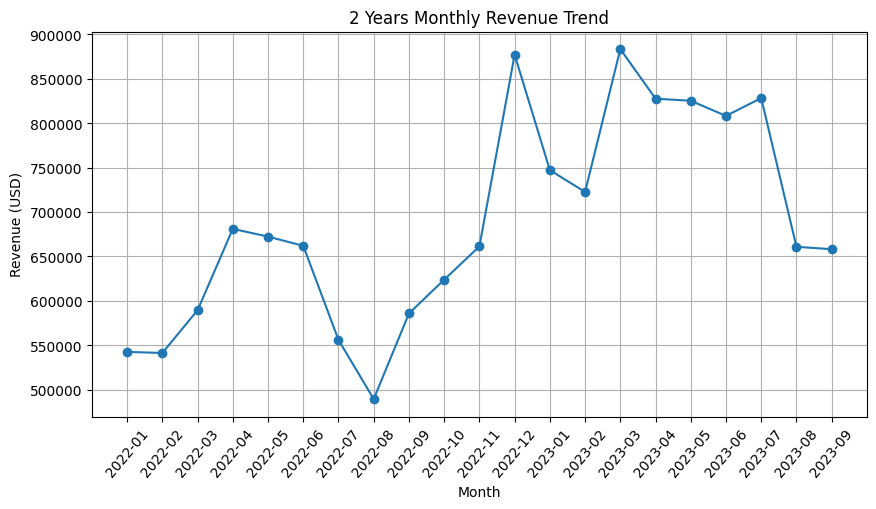

In [74]:
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("2 Years Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=50)
plt.grid(True)
plt.show()

<h3> Key Project Insights</h3>

<ul>
    <li><strong>Overall Trend:</strong> Sales grew steadily from early 2022 until mid-2023. However, there was a <span style="color:red;"><strong>sharp 20% drop in August 2023</strong></span>, and sales have stayed flat at around 660,000 since then.</li>
    <br>
    <li><strong>Highest Sales Month:</strong> <span style="color:green;"><strong>March 2023</strong></span> (~883,000) was the best month, right ahead of December 2022.</li>
    <br>
    <li><strong>Lowest Sales Month:</strong> <span style="color:red;"><strong>August 2022</strong></span> (~490,000) was the worst month, but sales recovered quickly right after.</li>
</ul>

<p style="background-color: #b003fa; padding: 10px; border-left: 4px solid #3498db;">
    <strong>Summary:</strong> The business was growing well for most of the two years, but you need to look into why sales suddenly dropped and flattened out at the end.
</p>

2.Which products are critical to the business?(ABC Product Analysis)

In [16]:
product_wise_revenue = master_data.groupby('product_name')['revenue'].sum().sort_values(ascending=False)

In [17]:
df_abc_products = product_wise_revenue.reset_index()

In [18]:
df_abc_products["cumulative_revenue"] = df_abc_products["revenue"].cumsum()


In [19]:
total_revenue = df_abc_products["revenue"].sum()

In [21]:
df_abc_products['cumulative_revenue_percentage'] = (df_abc_products['cumulative_revenue'] / total_revenue) * 100

In [22]:
df_abc_products.head()

,product_name,revenue,cumulative_revenue,cumulative_revenue_percentage
0,Lego Bricks,2388882.63,2388882.63,16.538272
1,Colorbuds,1564476.32,3953358.95,27.369166
2,Magic Sand,968962.02,4922320.97,34.077305
3,Action Figure,926748.42,5849069.39,40.493199
4,Rubik's Cube,912983.28,6762052.67,46.813796


In [23]:
def assign_category(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'
df_abc_products['Category'] = df_abc_products['cumulative_revenue_percentage'].apply(assign_category)

In [24]:
df_abc_products

,product_name,revenue,cumulative_revenue,cumulative_revenue_percentage,Category
0,Lego Bricks,2388882.63,2388882.63,16.538272,A
1,Colorbuds,1564476.32,3953358.95,27.369166,A
2,Magic Sand,968962.02,4922320.97,34.077305,A
3,Action Figure,926748.42,5849069.39,40.493199,A
4,Rubik's Cube,912983.28,6762052.67,46.813796,A
5,Deck Of Cards,587397.66,7349450.33,50.880359,A
6,Splash Balls,541629.52,7891079.85,54.630069,A
7,Nerf Gun,530594.57,8421674.42,58.303384,A
8,Animal Figures,507766.11,8929440.53,61.818656,A
9,Dart Gun,505092.12,9434532.65,65.315417,A


<div style="background-color: #ebf8ff; border-left: 6px solid #3182ce; padding: 20px; border-radius: 8px; font-family: sans-serif;">
    <h3 style="color: #2b6cb0; margin-top: 0; font-size: 20px; display: flex; align-items: center; gap: 8px;">
         Core Business Insight: Critical Products
    </h3>
    <p style="color: #2d3748; font-size: 15px; line-height: 1.6; margin: 0;">
        The critical products driving our business are the <strong>11 items from Lego Bricks down to the Kids Makeup Kit</strong>. 
        While they represent <span style="color: #e53e3e; font-weight: bold;">less than a third</span> of our total product count, they generate 
        <span style="background-color: #feebc8; color: #9c4221; padding: 2px 6px; font-weight: bold; border-radius: 4px;">68.7% (nearly 70%)</span> 
        of our total company revenue.
    </p>
    <div style="margin-top: 15px; padding-top: 12px; border-top: 1px solid #e2e8f0; color: #2b6cb0; font-weight: bold; font-size: 14px;">
        ⚠️ Operational Mandate: We must prioritize inventory and supply chain management for these specific items.
    </div>
</div>

3. Inventory Risk Analysis

In [25]:
inventory_sales=sales.merge(inventory, on=['store_id', 'product_id'], how='left')\
    .merge(stores, on='store_id', how='left')\
    .merge(products, on='product_id', how='left')

In [26]:
inventory_sales.head()

,sale_id,date,store_id,product_id,units,stock_on_hand,store_name,store_city,store_location,store_open_date,product_name,product_category,product_cost,product_price
0,1,2022-01-01,24,4,1,1.0,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99
1,2,2022-01-01,28,1,1,6.0,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99
2,3,2022-01-01,6,8,1,50.0,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,3.99,6.99
3,4,2022-01-01,48,7,1,28.0,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,11.99,15.99
4,5,2022-01-01,44,18,1,117.0,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,34.99,39.99


In [27]:
# 1. Group individual sales into daily totals
daily_sales = inventory_sales.groupby(['date', 'store_id', 'product_id'])['units'].sum().reset_index()
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

In [33]:
daily_sales.head()

,date,store_id,product_id,units
0,2022-01-01,1,21,35
1,2022-01-01,1,31,9
2,2022-01-01,1,34,4
3,2022-01-01,2,18,5
4,2022-01-01,3,8,6


In [34]:
# 2. Create a complete list of every date, store, and product combination
all_dates = pd.date_range(start=daily_sales['date'].min(), end=daily_sales['date'].max(), freq='D')
store_ids = daily_sales['store_id'].unique()
product_ids = daily_sales['product_id'].unique()



In [35]:
# 3. Reindex the dataset so missing sales days become 0 instead of skipping rows
full_index = pd.MultiIndex.from_product([all_dates, store_ids, product_ids], names=['date', 'store_id', 'product_id'])
daily_sales_complete = daily_sales.set_index(['date', 'store_id', 'product_id']).reindex(full_index, fill_value=0).reset_index()


In [36]:
daily_sales_complete.head()

,date,store_id,product_id,units
0,2022-01-01,1,21,35
1,2022-01-01,1,31,9
2,2022-01-01,1,34,4
3,2022-01-01,1,18,0
4,2022-01-01,1,8,0


In [37]:
daily_sales_complete.shape

(1116500, 4)

In [38]:

# 4. Sort correctly by group and date
daily_sales_complete = daily_sales_complete.sort_values(by=['store_id', 'product_id', 'date'])



In [39]:
daily_sales_complete.head()

,date,store_id,product_id,units
6,2022-01-01,1,1,0
1756,2022-01-02,1,1,9
3506,2022-01-03,1,1,0
5256,2022-01-04,1,1,6
7006,2022-01-05,1,1,0


In [41]:
daily_sales_complete['rolling_daily_sales'] = daily_sales_complete.groupby(['store_id', 'product_id'])['units'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

In [42]:
daily_sales_complete.head()

,date,store_id,product_id,units,rolling_daily_sales
6,2022-01-01,1,1,0,0.00
1756,2022-01-02,1,1,9,4.50
3506,2022-01-03,1,1,0,3.00
5256,2022-01-04,1,1,6,3.75
7006,2022-01-05,1,1,0,3.00


In [43]:
# Extract the latest date for each store/product asset to see current velocity
latest_velocity = daily_sales_complete.drop_duplicates(subset=['store_id', 'product_id'], keep='last')


In [44]:
latest_velocity.head()

,date,store_id,product_id,units,rolling_daily_sales
1114756,2023-09-30,1,1,0,2.428571
1114768,2023-09-30,1,2,0,3.285714
1114761,2023-09-30,1,3,0,3.428571
1114763,2023-09-30,1,4,0,0.000000
1114773,2023-09-30,1,5,5,2.428571


In [45]:
# Get a clean, unique layout of actual stock numbers and descriptions
clean_inventory = inventory_sales[['store_id', 'store_name', 'store_city', 'product_id', 'product_name', 'stock_on_hand']].drop_duplicates()



In [46]:
clean_inventory.head()

,store_id,store_name,store_city,product_id,product_name,stock_on_hand
0,24,Maven Toys Aguascalientes 1,Aguascalientes,4,Chutes & Ladders,1.0
1,28,Maven Toys Puebla 2,Puebla,1,Action Figure,6.0
2,6,Maven Toys Mexicali 1,Mexicali,8,Deck Of Cards,50.0
3,48,Maven Toys Saltillo 2,Saltillo,7,Dart Gun,28.0
4,44,Maven Toys Puebla 3,Puebla,18,Lego Bricks,117.0


In [47]:
clean_inventory.shape

(1631, 6)

In [48]:
# Merge clean stock levels with your true rolling velocity trends
risk_report = pd.merge(clean_inventory, latest_velocity[['store_id', 'product_id', 'rolling_daily_sales']], on=['store_id', 'product_id'], how='left')


In [49]:
type(risk_report)

pandas.core.frame.DataFrame

In [51]:
risk_report['stock_on_hand'] = risk_report['stock_on_hand'].fillna(0)
risk_report['rolling_daily_sales'] = risk_report['rolling_daily_sales'].fillna(0)



In [52]:
# Run the definitive days remaining formula
risk_report['days_remaining'] = risk_report['stock_on_hand'] / risk_report['rolling_daily_sales']



In [53]:
# Handle infinite values cleanly (when sales are 0 but stock exists)
risk_report['days_remaining'] = risk_report['days_remaining'].replace([np.inf, -np.inf], 999)



In [54]:
final_stockout_analysis = risk_report.sort_values(by='days_remaining', ascending=True)


In [55]:
final_stockout_analysis.head()

,store_id,store_name,store_city,product_id,product_name,stock_on_hand,rolling_daily_sales,days_remaining
1624,22,Maven Toys Guanajuato 2,Guanajuato,28,Playfoam,0.0,6.142857,0.0
1629,13,Maven Toys Mexicali 2,Mexicali,28,Playfoam,0.0,0.571429,0.0
1591,24,Maven Toys Aguascalientes 1,Aguascalientes,28,Playfoam,0.0,1.000000,0.0
674,36,Maven Toys Morelia 1,Morelia,4,Chutes & Ladders,0.0,1.000000,0.0
951,35,Maven Toys Chilpancingo 1,Chilpancingo,15,Hot Wheels 5-Pack,0.0,1.857143,0.0


In [53]:
pd.set_option('display.max_rows',None)

In [56]:
def determine_risk_style(row):
  
    days = row['days_remaining']
    
    # 1. Start with a clean slate: make all columns normal/white by default
    styles = [''] * len(row)
    
    # 2. Update ONLY the last column's style (index -1 refers to the very last column)
    if days <= 3:
        styles[-1] = ' background-color: #ffffff; color: #9b2c2c; font-weight: bold'
    
    elif 3 < days <= 7:
        styles[-1] = 'background-color: #ffffff; color: #9c4221; font-weight: bold'
    elif 7< days<=30:
        styles[-1] = 'background-color: #ffffff; color: #234e52; font-weight: bold'
    
    else:
        styles[-1] = 'background-color: #ffffff; color: #2787F5; font-weight: bold'
        
    return styles

In [57]:
def assign_status_label(days):
    if days == 0:
        return "Immediate Stockout"
    elif 0 < days <= 3:
        return "Critical Risk (<3 Days)"
    elif 3 < days <= 7:
        return "Medium Risk (4-7 Days)"
    elif 7 < days <= 30:
        return "Safe"
    else:
        return "Overstocked (>30 Days)"

final_stockout_analysis['Risk_Status'] = final_stockout_analysis['days_remaining'].apply(assign_status_label)

In [77]:
# Select the most important columns for the final presentation
presentation_df = final_stockout_analysis[[
    'store_name', 'store_city', 'product_name', 
    'stock_on_hand', 'rolling_daily_sales', 'days_remaining', 'Risk_Status'
]].head()
# Apply the custom row-by-row styling rules
presentation_df.style.apply(determine_risk_style, axis=1)

,store_name,store_city,product_name,stock_on_hand,rolling_daily_sales,days_remaining,Risk_Status
1624,Maven Toys Guanajuato 2,Guanajuato,Playfoam,0.000000,6.142857,0.000000,Immediate Stockout
1629,Maven Toys Mexicali 2,Mexicali,Playfoam,0.000000,0.571429,0.000000,Immediate Stockout
1591,Maven Toys Aguascalientes 1,Aguascalientes,Playfoam,0.000000,1.000000,0.000000,Immediate Stockout
674,Maven Toys Morelia 1,Morelia,Chutes & Ladders,0.000000,1.000000,0.000000,Immediate Stockout
951,Maven Toys Chilpancingo 1,Chilpancingo,Hot Wheels 5-Pack,0.000000,1.857143,0.000000,Immediate Stockout


<div style="border-left:5px solid #dc3545; background:#fffff; padding:15px; border-radius:8px; font-family:Arial, sans-serif;">

<h3>🚨 Key Insight: Immediate Stockout Risk</h3>

<p>
Analysis identified <strong>20 different products</strong> that are currently in an
<strong>Immediate Stockout</strong> state across multiple stores. These products have
<strong>zero inventory</strong> and <strong>0 days remaining</strong>, while still exhibiting
positive rolling daily sales, indicating ongoing customer demand.
</p>

<p>
This situation represents a significant risk of
<strong>lost sales, reduced customer satisfaction, and potential revenue loss</strong>.
Immediate inventory replenishment should be prioritized for these products to restore
availability and minimize business impact.
</p>

</div>

4. Are there different types of stores?

In [79]:
inventory_sales.head()

,sale_id,date,store_id,product_id,units,stock_on_hand,store_name,store_city,store_location,store_open_date,product_name,product_category,product_cost,product_price,revenue
0,1,2022-01-01,24,4,1,1.0,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99,12.99
1,2,2022-01-01,28,1,1,6.0,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99,15.99
2,3,2022-01-01,6,8,1,50.0,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,3.99,6.99,6.99
3,4,2022-01-01,48,7,1,28.0,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,11.99,15.99,15.99
4,5,2022-01-01,44,18,1,117.0,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,34.99,39.99,39.99


In [60]:
inventory_sales['revenue']=inventory_sales["units"]*inventory_sales["product_price"]

In [61]:
stores_revenue=(inventory_sales.groupby(["store_id","store_name"])["revenue"].sum().reset_index())

In [62]:
units_sold=inventory_sales.groupby(["store_id"])["units"].sum().reset_index()

In [63]:
stores_revenue_stock=pd.merge(stores_revenue,units_sold,on="store_id",how="left")

In [64]:
stock_on_hand=inventory.groupby(["store_id"])["stock_on_hand"].sum().reset_index()

In [65]:
stores_revenue_stock=pd.merge(stores_revenue_stock,stock_on_hand,on="store_id",how="left")

In [69]:
stores_revenue_stock.sort_values("store_id",ascending=True).head(10)

,store_id,store_name,revenue,units,stock_on_hand
0,1,Maven Toys Guadalajara 1,261842.89,20011,563
1,2,Maven Toys Monterrey 1,277959.14,20886,516
2,3,Maven Toys Guadalajara 2,262435.02,20698,514
3,4,Maven Toys Saltillo 1,330408.90,24010,437
4,5,Maven Toys La Paz 1,210897.83,16217,473
5,6,Maven Toys Mexicali 1,294019.42,22858,679
6,7,Maven Toys Monterrey 2,372998.82,28318,558
7,8,Maven Toys Pachuca 1,237676.15,19185,548
8,9,Maven Toys Ciudad de Mexico 1,433556.21,33479,579
9,10,Maven Toys Campeche 1,311786.44,24556,657


In [70]:
stores_revenue_stock["units"].sum()

np.int64(1090565)

In [166]:
X=stores_revenue_stock[["revenue","stock_on_hand","units"]]

In [167]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [176]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


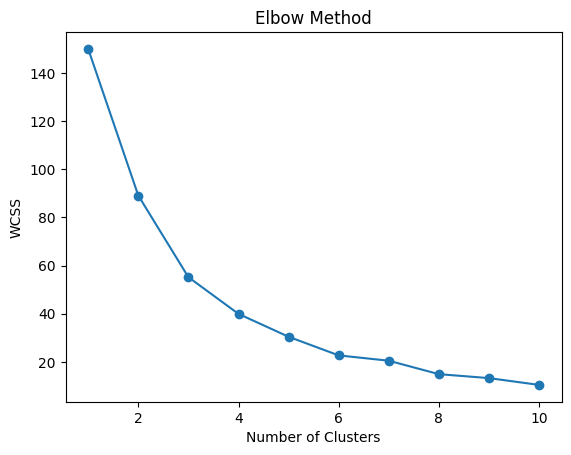

In [177]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [171]:

kmeans = KMeans(n_clusters=3, random_state=42)

stores_revenue_stock['Cluster'] = kmeans.fit_predict(X_scaled)

In [175]:
stores_revenue_stock.groupby('Cluster')[["revenue","stock_on_hand","units"]].mean()

,revenue,stock_on_hand,units
Cluster,,,
0,264917.889630,515.148148,19977.703704
1,281676.035556,698.388889,21240.888889
2,444324.138000,652.400000,33766.200000


Overall Business Insight

💡 Store clustering reveals three distinct performance segments: High-, Medium-, and Low-performing stores. High-performing stores achieve significantly greater revenue and sales without carrying the largest inventory, highlighting superior inventory efficiency. Medium-performing stores hold the most inventory but do not achieve proportionally higher sales, while low-performing stores exhibit both lower demand and lower revenue. These insights can guide inventory allocation, replenishment strategies, and targeted business improvements.

5. Does inventory level impact sales?

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns


In [89]:
cor_units_sold=inventory_sales.groupby("product_id")["units"].sum().reset_index()

In [92]:
corr_stock=inventory.groupby("product_id")["stock_on_hand"].sum().reset_index()

In [93]:
corr_inventory_sales=pd.merge(cor_units_sold,corr_stock,on="product_id")

In [94]:
corr_inventory_sales.sort_values("units",ascending=True).head()

,product_id,units,stock_on_hand
19,20,2647,234
34,35,2710,241
21,22,3385,207
3,4,3829,255
27,28,4158,357


In [95]:
corr_inventory_sales[["units","stock_on_hand"]].corr()

,units,stock_on_hand
units,1.000000,0.709321
stock_on_hand,0.709321,1.000000


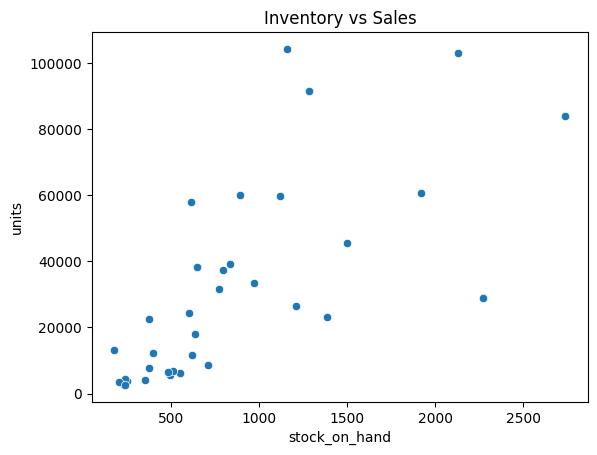

In [206]:

sns.scatterplot(
    data=corr_inventory_sales,
    x='stock_on_hand',
    y='units'
)

plt.title("Inventory vs Sales")
plt.show()

<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width:750px; background-color: #1a202c; color: #fff; padding: 24px; border-radius: 12px; border: 1px solid #2d3748; box-shadow: 0 4px 15px rgba(0,0,0,0.3);">
  
  <div style="display: flex; align-items: center; margin-bottom: 16px;">
    <div style="background-color: #04f7fb; color: #000000; padding: 12px 12px; border-radius: 10px; font-weight: bold; font-size: 20px; margin-right: 12px;">
      STRATEGIC INSIGHT
    </div>
    <h3 style="margin: 0; font-size: 18px; color: #fffdfd; font-weight: 600;">Product-Level Inventory vs. Sales</h3>
  </div>

  <hr style="border: 0; border-top: 1px solid #000000; margin-bottom: 16px;" />

  <p style="margin: 0 0 16px 0; font-size: 15px; line-height: 1.6; color: #cbd5e0;">
    Aggregating data by <strong style="color: #4fd1c5;">product_id</strong> reveals a clear, positive linear trend. Unlike noisy day-to-day transaction records, macro product analysis proves that high inventory allocation strongly aligns with high-velocity sales.
  </p>

  <div style="background-color: #2d3748; padding: 14px; border-radius: 8px; font-size: 14px; line-height: 1.5;">
    <ul style="margin: 0; padding-left: 20px; color: #e2e8f0;">
      <li style="margin-bottom: 8px;"><strong style="color: #01f54a;">Efficient Movers:</strong> A tight cluster turns over ~60k units while maintaining lean capital investments under 1k stock units.</li>
      <li><strong style="color: #fd0808;">Overstocked Outliers:</strong> At least one distinct product hoards over 2.2k inventory units while generating suboptimal sales, marking an immediate candidate for markdowns or paused replenishment.</li>
    </ul>
  </div>

</div>